# Data Cleaning

This notebook cleans and prepares the raw OpenStreetMap building data for subsequent classification and feature engineering. It resolves missing values, invalid geometries and identifier artefacts, removes low-value attributes, standardizes building-level information, and derives basic address and geometric features.

**Input**
- Raw OpenStreetMap building data for Germany.

**Output**
- Cleaned building data with standardized attributes and valid geometries.
- Basic derived features for subsequent classification and feature engineering.

In [12]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import sys
import re


ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [13]:
print("Loading Germany Data...")

# 1. Load Parquet files
gdf_bldg = gpd.read_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings.parquet'))

print("Data loaded successfully!")

Loading Germany Data...
Data loaded successfully!


### Fix Fake Nulls

When OSM data is serialised to Parquet, Python `None` values sometimes become the *string* `'nan'`, `'None'`, or `''` instead of a real `NaN`.

- Scan all `object`-dtype columns. Replace any string that is a known null-alias with `np.nan`.

In [14]:
FAKE_NULLS = {'nan', 'NaN', 'None', 'none', '', ' ', 'NULL', 'null'}

def replace_fake_nulls(gdf, name='dataset'):
    replaced = 0
    for col in gdf.select_dtypes(include=['object']).columns:
        if col == 'geometry':
            continue
        mask = gdf[col].isin(FAKE_NULLS)
        n = mask.sum()
        if n > 0:
            gdf.loc[mask, col] = np.nan
            replaced += n
    print(f'[{name}] Replaced {replaced:,} fake-null strings with np.nan')
    return gdf

gdf_bldg    = replace_fake_nulls(gdf_bldg,    'buildings')


[buildings] Replaced 1,266,285,628 fake-null strings with np.nan


### Geometry Filtering
A building footprint must be a polygon. During EDA, we discovered a negligible fraction (30 rows) of `LineString` and `MultiLineString` geometries. These are mapping errors and cannot be used to calculate area or volume.
- Keep only rows where geometry type is `Polygon` or `MultiPolygon`.

In [15]:
VALID_GEOM_TYPES = {'Polygon', 'MultiPolygon'}

before = len(gdf_bldg)
gdf_bldg = gdf_bldg[gdf_bldg.geometry.geom_type.isin(VALID_GEOM_TYPES)].copy()
after_geo_filtering = len(gdf_bldg)

print(f'Rows before : {before:,}')
print(f'Rows after  : {after_geo_filtering:,}')
print(f'Dropped     : {before - after_geo_filtering:,}  ({(before-after_geo_filtering)/before*100:.5f}%)')
print()
print('Remaining geometry types:')
print(gdf_bldg.geometry.geom_type.value_counts().to_string())


Rows before : 38,830,003
Rows after  : 38,829,973
Dropped     : 30  (0.00008%)

Remaining geometry types:
Polygon         38828150
MultiPolygon        1823


### Topology Correction (Fixing Invalid Geometries)
OpenStreetMap geometries are drawn manually by users, so they sometimes contain topological errors, such as self-intersecting lines (creating "bowtie" or figure-8 shapes). GeoPandas flags these as `invalid`. If left unhandled, these broken geometries will cause downstream spatial operations (like calculating footprint area or performing spatial joins with landuse data) to fail or return incorrect values.

1. We apply a `.buffer(0)` geometric operation, which is a standard GIS technique to repair self-intersections. Often, this splits a broken Polygon into a clean `MultiPolygon`.
2. Because `.buffer(0)` is highly computationally expensive, we do not apply it to the entire dataset. We use a boolean mask to apply it *selectively* only to the invalid rows, saving massive compute time.
3. Any geometries that remain invalid or become completely empty after the fix are safely dropped.

In [16]:
invalid_before = (~gdf_bldg.geometry.is_valid).sum()
empty_before   = gdf_bldg.geometry.is_empty.sum()
print(f'Invalid geometries before fix : {invalid_before:,}')
print(f'Empty geometries before fix   : {empty_before:,}')
print()
print('Applying .buffer(0) to invalid geometries...')

broken_indices = gdf_bldg[~gdf_bldg.geometry.is_valid].index

# Fix only invalid ones (buffer is expensive at 38 M rows — apply selectively)
invalid_mask = ~gdf_bldg.geometry.is_valid
gdf_bldg.loc[invalid_mask, 'geometry'] = gdf_bldg.loc[invalid_mask, 'geometry'].buffer(0)

# Drop any that are still invalid or now empty after buffering
still_invalid = ~gdf_bldg.geometry.is_valid
still_empty   = gdf_bldg.geometry.is_empty
drop_mask     = still_invalid | still_empty
n_drop        = drop_mask.sum()
gdf_bldg = gdf_bldg[~drop_mask].copy()

after_invalid_fix = len(gdf_bldg)

print(f'Fixed with buffer(0)          : {invalid_before - n_drop:,}')
print(f'Dropped (unfixable/empty)     : {n_drop:,}')
print(f'Remaining invalid             : {(~gdf_bldg.geometry.is_valid).sum():,}  ← should be 0')
print(f'Rows remaining                : {after_invalid_fix:,}')


Invalid geometries before fix : 50,575
Empty geometries before fix   : 0

Applying .buffer(0) to invalid geometries...
Fixed with buffer(0)          : 50,520
Dropped (unfixable/empty)     : 55
Remaining invalid             : 0  ← should be 0
Rows remaining                : 38,829,918


In [17]:
print(f"MultiPolygons after: {(gdf_bldg.geom_type == 'MultiPolygon').sum():,}")

MultiPolygons after: 5,766


### Resolve Duplicate OSM IDs & Drop Relations

During EDA, we found **89 duplicate `id` values** with 12 rows having suspiciously small IDs (`1`, `2`, `5` … `86`) with the same `id` **and** same `osm_type`. Investigation showed that they were not duplicate buildings as their geometries were far apart.

To investigate further, manual inspection was carried out for the small ids and for osm_type = relation, of which it was found  that 99% of the data don't exist on openstreetmap and the remaining 1% have been deprecated, deleted or contained an entirely different footprint.

As a result of this, it is important to drop all rows with relations and osm id's that are 6 digits or smaller.




In [18]:
print("--- Cleaning Corrupted OSM Types ---")

initial_count = len(gdf_bldg)
relations_count = (gdf_bldg['osm_type'] == 'relation').sum()

print(f"Total rows before cleaning: {initial_count:,}")
print(f"Identified {relations_count:,} 'relation' types for removal.")

# Keep only rows where osm_type is NOT 'relation'
gdf_bldg = gdf_bldg[gdf_bldg['osm_type'] != 'relation'].copy()

after_relation_drop = len(gdf_bldg)

print(f"Dataset size after dropping relations: {after_relation_drop:,}")

--- Cleaning Corrupted OSM Types ---


Total rows before cleaning: 38,829,918
Identified 27,470 'relation' types for removal.
Dataset size after dropping relations: 38,802,448


In [19]:
print("── Checking for UID Artefacts & Collisions ───────────────────────")

# 1. Find all rows where the composite 'id' is duplicated 
# (keep=False marks ALL copies of the duplicate as True so we can see them)
duped_uid_mask = gdf_bldg['id'].duplicated(keep=False)

print(f"Rows with duplicated id : {duped_uid_mask.sum():,}")

if duped_uid_mask.sum() > 0:
    print('\nArtefact rows (UID Collisions):')
    # Display the problematic rows to inspect why they have the same UID
    display(gdf_bldg[duped_uid_mask][['id', 'osm_type', 'building', 'geometry']].head(20))


── Checking for UID Artefacts & Collisions ───────────────────────
Rows with duplicated id : 24

Artefact rows (UID Collisions):


,id,osm_type,building,geometry
6153143,5,way,yes,"POLYGON ((13.80014 52.82743, 13.80023 52.82744..."
6156619,9,way,yes,"POLYGON ((13.80489 52.82765, 13.80523 52.82773..."
6156620,15,way,yes,"POLYGON ((13.80527 52.8277, 13.80534 52.82773,..."
6156624,15,way,yes,"POLYGON ((13.80546 52.82753, 13.80551 52.82755..."
6156625,9,way,yes,"POLYGON ((13.80458 52.82754, 13.80466 52.82754..."
6156631,1,way,yes,"POLYGON ((13.80433 52.82796, 13.80436 52.8279,..."
6156632,5,way,yes,"POLYGON ((13.80424 52.8278, 13.80433 52.82782,..."
6156635,17,way,yes,"POLYGON ((13.80568 52.82806, 13.80572 52.82809..."
6156636,2,way,yes,"POLYGON ((13.80454 52.82798, 13.80461 52.82799..."
6156637,17,way,yes,"POLYGON ((13.8054 52.82759, 13.80537 52.82758,..."


In [20]:
print("Inspecting short OSM IDs...")

# Create a boolean mask directly (NO new columns added to gdf_bldg)
short_id_mask = gdf_bldg['id'].astype(str).str.len() < 7

# Isolate the weird IDs into their own dataframe to inspect
weird_ids = gdf_bldg[short_id_mask]
print(f"Found {len(weird_ids)} buildings with suspiciously short IDs.")

if len(weird_ids) > 0:
    with pd.option_context('display.max_rows', None):
   
        # Display the first 10 for inspection (adjust columns as needed)
        display(weird_ids[['id', 'building', 'geometry']])



Inspecting short OSM IDs...
Found 76 buildings with suspiciously short IDs.


,id,building,geometry
6153143,5,yes,"POLYGON ((13.80014 52.82743, 13.80023 52.82744..."
6156618,12,yes,"POLYGON ((13.80522 52.82759, 13.80531 52.82761..."
6156619,9,yes,"POLYGON ((13.80489 52.82765, 13.80523 52.82773..."
6156620,15,yes,"POLYGON ((13.80527 52.8277, 13.80534 52.82773,..."
6156621,13,yes,"POLYGON ((13.80546 52.82767, 13.8055 52.82769,..."
6156622,10,yes,"POLYGON ((13.80482 52.82753, 13.80488 52.82753..."
6156623,14,yes,"POLYGON ((13.80551 52.82756, 13.80559 52.82758..."
6156624,15,yes,"POLYGON ((13.80546 52.82753, 13.80551 52.82755..."
6156625,9,yes,"POLYGON ((13.80458 52.82754, 13.80466 52.82754..."
6156626,11,yes,"POLYGON ((13.80491 52.82753, 13.80497 52.82753..."


In [21]:
# Drop artefact rows with very small IDs 

ID_DIGIT_THRESHOLD = 7

# Identify small IDs that are also duplicated (same osm_type)
small_id_mask = gdf_bldg['id'].astype(str).str.len() < ID_DIGIT_THRESHOLD
duped_id     = gdf_bldg['id'].duplicated(keep=False)
artefact_mask = small_id_mask & duped_id

print(f'Rows with small IDs (<{ID_DIGIT_THRESHOLD} digits): {small_id_mask.sum():,}')
print(f'Rows with small IDs (<{ID_DIGIT_THRESHOLD} digits) AND duplicated id : {artefact_mask.sum():,}')
print()
print('Artefact rows:')
print(gdf_bldg[artefact_mask][['id', 'osm_type', 'building', 'name']].to_string())

gdf_bldg = gdf_bldg[~small_id_mask].copy()
print(f'\nRows after small_id removal : {len(gdf_bldg):,}')
print(f'Remaining ID duplicates    : {gdf_bldg["id"].duplicated().sum()}')


Rows with small IDs (<7 digits): 76
Rows with small IDs (<7 digits) AND duplicated id : 24

Artefact rows:
          id osm_type building  name
6153143    5      way      yes   NaN
6156619    9      way      yes   NaN
6156620   15      way      yes   NaN
6156624   15      way      yes   NaN
6156625    9      way      yes   NaN
6156631    1      way      yes   NaN
6156632    5      way      yes   NaN
6156635   17      way      yes   NaN
6156636    2      way      yes   NaN
6156637   17      way      yes   NaN
12288008   1      way   stable   NaN
12288009   2      way   stable   NaN
36160921  86      way      yes   S13
36160922  86      way      yes    S6
36160930  70      way      yes  Mu54
36160934  70      way      yes  Mu53
36160938  61      way      yes  Mu59
36160941  56      way      yes   D47
36160942  55      way      yes   D46
36160944  61      way      yes   NaN
36160945  50      way      yes   NaN
36163892  56      way      yes   B66
36163893  55      way      yes   B65
36163

/tmp/ipykernel_94897/2014836380.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")


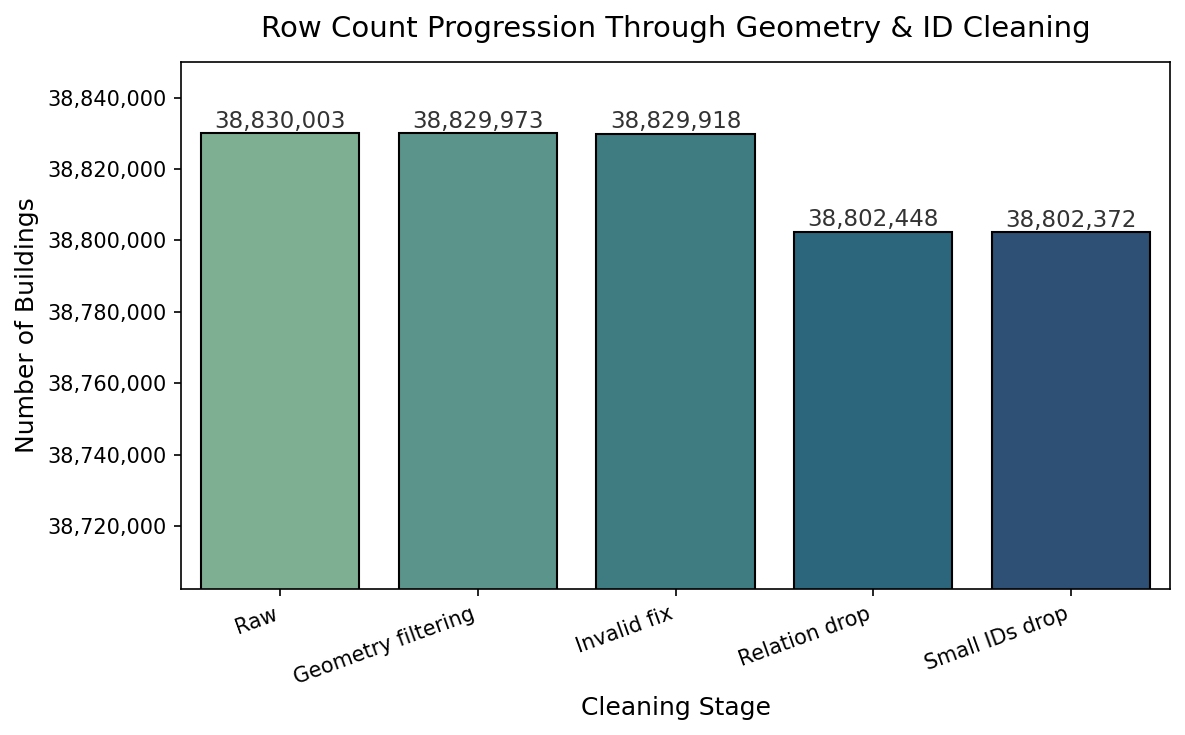

In [22]:
stages = ['Raw', 'Geometry filtering', 'Invalid fix',
    'Relation drop', 'Small IDs drop']

counts = [before, after_geo_filtering, after_invalid_fix, after_relation_drop, len(gdf_bldg)]

# Compute zoom range
min_val = min(counts)
max_val = max(counts)

# Add margin for readability
lower = min_val - 100000
upper = max_val + 20000

plt.figure(figsize=(8, 5), dpi=150)

ax = sns.barplot(x=stages, y=counts, palette="crest", edgecolor="black")

plt.title("Row Count Progression Through Geometry & ID Cleaning", fontsize=14, pad=12)
plt.ylabel("Number of Buildings", fontsize=12)
plt.xlabel("Cleaning Stage", fontsize=12)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.ylim(lower, upper)
plt.xticks(rotation=20, ha='right')

# Add labels above bars
for i, c in enumerate(counts):
    ax.text(i, c + (upper - lower) * 0.01, f"{c:,}", ha="center", fontsize=11, color="#333")

plt.tight_layout()
plt.show()


In [23]:
gdf_bldg.to_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned.parquet'), index=False)

In [24]:
gdf_bldg = gpd.read_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned.parquet'))

### Drop Low-Value Columns

The EDA completeness scan showed many columns with near-zero fill rates that contain no classification signal (contact info, metadata, provenance). 

Drop groups:
- **Contact/web columns** (`email`, `phone`, `url`, `website`, `wikipedia`) — irrelevant to building type
- **OSM metadata** (`timestamp`, `version`, `changeset`, `visible`, `source`) — provenance, not features
- **`levels`** — only 77 values in the whole country; `building:levels` covers the same concept 3000× better
- **`building:flats`** — 0.042% coverage; useful pattern already noted in EDA but too sparse to be a model feature
- osm-type - only ways exist
- heights - unreliable

Only keep useful columns: address columns, 'building:levels', 'name', 
- building, 'amenity',  'building:use', 'shop' - stage 1 classification
- 'craft', 'office - ruble based classification for semi commercial buildings (if either appear where building is residential)
- id, tags, geometry



In [25]:
USEFUL_COLUMNS = ['addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street',
       'name', 'building', 'amenity', 'building:levels', 'building:use', 
       'craft', 'office', 'shop', 'id', 'tags', 'geometry']

In [26]:
# Only keep columns that are in our USEFUL_COLUMNS list (some may be missing due to OSM data variability)
print(f'\nColumns before : {len(gdf_bldg.columns)}')

available_cols = [col for col in USEFUL_COLUMNS if col in gdf_bldg.columns]
missing_cols   = [col for col in USEFUL_COLUMNS if col not in gdf_bldg.columns]

gdf_bldg = gdf_bldg[available_cols].copy()

print(f'Columns after  : {len(gdf_bldg.columns)}')
print(f'Remaining      : {available_cols}')

if missing_cols:
    print(f'Missing cols   : {missing_cols}')


Columns before : 43
Columns after  : 15
Remaining      : ['addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'name', 'building', 'amenity', 'building:levels', 'building:use', 'craft', 'office', 'shop', 'id', 'tags', 'geometry']


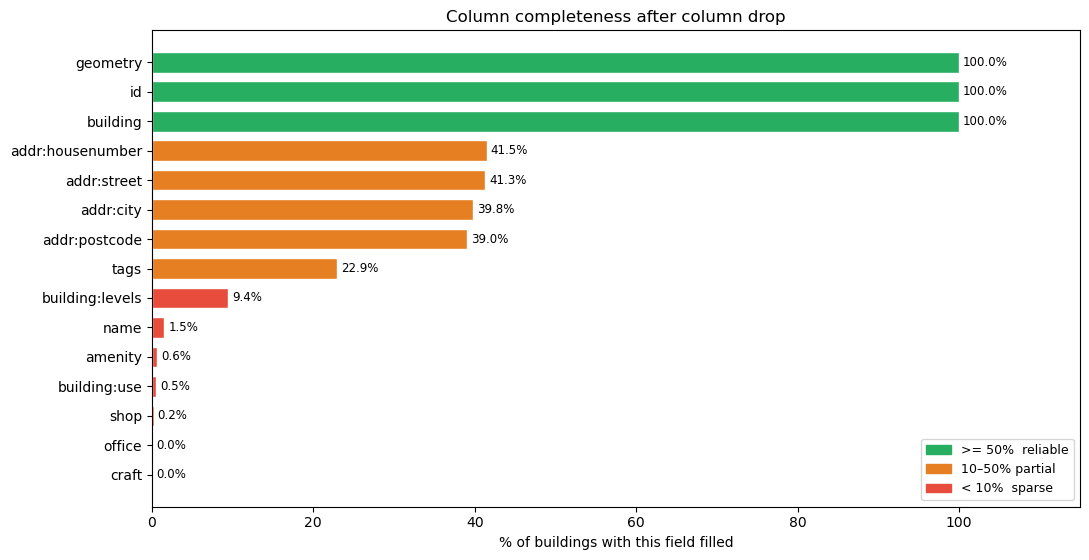

In [27]:
# ── Plot: column completeness after dropping ─────────────────────────
comp = (gdf_bldg[available_cols].notna().sum() / len(gdf_bldg) * 100).sort_values()

colors_bar = ['#27ae60' if v >= 50 else '#e67e22' if v >= 10 else '#e74c3c'
              for v in comp]

fig, ax = plt.subplots(figsize=(11, max(5, len(comp) * 0.38)))
bars = ax.barh(comp.index, comp.values, color=colors_bar, edgecolor='white', height=0.7)
for bar, val in zip(bars, comp.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8.5)
patches = [
    mpatches.Patch(color='#27ae60', label='>= 50%  reliable'),
    mpatches.Patch(color='#e67e22', label='10–50% partial'),
    mpatches.Patch(color='#e74c3c', label='< 10%  sparse'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
ax.set_xlabel('% of buildings with this field filled')
ax.set_xlim(0, 115)
ax.set_title('Column completeness after column drop')
plt.tight_layout(); plt.show()



### Clean `building:levels`

`building:levels` has **9.44% coverage** — 17× better than height. The EDA confirmed it produces three clearly interpretable tiers (tall/medium/low). However, the raw values contain:
- German notation: `EG` (Erdgeschoss = ground floor only = 1), `DG` (Dachgeschoss = attic)
- Attic suffix: `1+D` → 2, `2+D` → 3
- German decimal commas: `1,5` → 2 (round up for mezzanine)
- Semicolon ranges: `1;2` → take max
- Non-numeric junk: `yes`, `no`, long strings



In [28]:
def compile_config_patterns(config):
    config['attic_pattern'] = re.compile(
        r'^(\d+\.?\d*)\s*\+\s*(?:' + '|'.join(config['attic_terms']) + r')$'
    )
    config['ground_pattern'] = re.compile(
        r'^(?:' + '|'.join(config['ground_terms']) + r')\+(\d+)$'
    )
    # Fixed: Removed the stray 's?' from the end of this regex
    config['word_pattern'] = re.compile(
        r'^(\d+\.?\d*)\s*(?:' + '|'.join(config['floor_words']) + r')$'
    )
    config['range_pattern'] = re.compile(r'^(\d+\.?\d*)[–\-](\d+\.?\d*)$')
    return config

CONFIG_GERMANY = compile_config_patterns({
    'max_floors': 60,
    'min_floors': 1,
    'ground_terms': ['eg', 'g', 'erdgeschoss', 'ground', 'gf'], # <-- Added 'g'
    'attic_terms': ['d', 'dg', 'dachgeschoss', 'attic'],
    'floor_words': ['etagen?', 'geschoss(?:e)?', 'stockwerk(?:e)?', 'floors?', 'levels?', 'étages?']
})

CONFIG_GLOBAL = compile_config_patterns({
    'max_floors': 165,
    'min_floors': 1,
    'ground_terms': ['ground', 'g', 'gf', 'rc', 'rez-de-chaussee', 'planta baja', 'pb'],
    'attic_terms': ['attic', 'loft', 'roof', 'combles', 'atico'],
    'floor_words': ['floors?', 'stories', 'levels?', 'etages?', 'pisos?']
})


def validate(val, config):
    if pd.isna(val):
        return np.nan
    
    # Restores your max(1, val) logic: bumps '0' floors up to '1'
    val = max(config['min_floors'], int(val))
    
    # Only check the upper bound now
    if val <= config['max_floors']:
        return val
    return np.nan


def clean_levels(val, config=CONFIG_GERMANY):
    if pd.isna(val):
        return np.nan

    s = str(val).strip().lower().replace(',', '.')

    # Remove basement notation safely (e.g. "+ 1b")
    s = re.sub(r'\+\s*\d*\s*b', '', s)

    if s in config['ground_terms']:
        return validate(1, config)

    attic_match = config['attic_pattern'].match(s)
    if attic_match:
        return validate(np.ceil(float(attic_match.group(1))) + 1, config)

    ground_match = config['ground_pattern'].match(s)
    if ground_match:
        return validate(int(ground_match.group(1)) + 1, config)

    word_match = config['word_pattern'].match(s)
    if word_match:
        return validate(np.ceil(float(word_match.group(1))), config)

    # Restored your exact semicolon logic
    if ';' in s:
        nums = []
        for p in s.split(';'):
            try:
                n = float(p.strip())
                if n > 0:
                    nums.append(n)
            except:
                pass
        if nums:
            return validate(np.ceil(max(nums)), config)

    range_match = config['range_pattern'].match(s)
    if range_match:
        return validate(np.ceil(float(range_match.group(2))), config)

    # General fallback
    s_clean = re.sub(r'[a-zA-ZäöüÄÖÜ\s\+\(\)]', '', s).strip()
    try:
        val_f = float(s_clean)
        return validate(np.ceil(val_f), config)
    except:
        return np.nan


gdf_bldg['levels_clean'] = gdf_bldg['building:levels'].apply(clean_levels)

raw_lev   = gdf_bldg['building:levels'].notna().sum()
clean_lev = gdf_bldg['levels_clean'].notna().sum()

print(f'Raw building:levels non-null   : {raw_lev:,}')
print(f'Cleaned levels_clean non-null  : {clean_lev:,}')
if raw_lev > 0:
    print(f'Recovery rate                  : {clean_lev/raw_lev*100:.2f}%')

print("\nDistribution (top 15):")
print(gdf_bldg['levels_clean'].value_counts().head(15).to_string())

Raw building:levels non-null   : 3,656,615
Cleaned levels_clean non-null  : 3,656,602
Recovery rate                  : 100.00%

Distribution (top 15):
levels_clean
2.0     1449266
1.0     1390381
3.0      405087
4.0      240479
5.0      106610
6.0       33962
7.0       10132
8.0        8696
9.0        4185
11.0       2099
10.0       1822
12.0        984
13.0        578
14.0        563
15.0        428


In [29]:
print(gdf_bldg['levels_clean'].describe().round(1).to_string())

count    3656602.0
mean           2.0
std            1.3
min            1.0
25%            1.0
50%            2.0
75%            2.0
max           60.0


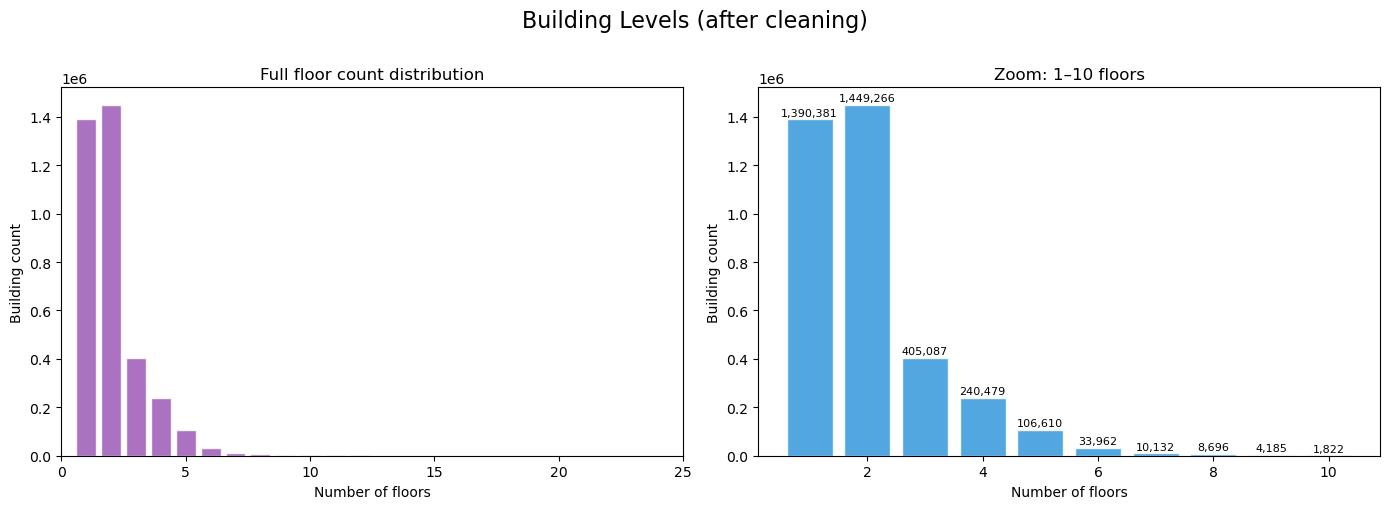

In [30]:
# ── Plot: floor count distribution ───────────────────────────────────
lev_counts = gdf_bldg['levels_clean'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].bar(lev_counts.index, lev_counts.values, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of floors'); axes[0].set_ylabel('Building count')
axes[0].set_title('Full floor count distribution')
axes[0].set_xlim(0, 25)

# Zoom on 1–10
lev_zoom = lev_counts[lev_counts.index <= 10]
axes[1].bar(lev_zoom.index, lev_zoom.values, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of floors'); axes[1].set_ylabel('Building count')
axes[1].set_title('Zoom: 1–10 floors')
for x, y in zip(lev_zoom.index, lev_zoom.values):
    axes[1].text(x, y + max(lev_zoom.values)*0.01, f'{y:,}', ha='center', fontsize=8)

plt.suptitle('Building Levels (after cleaning)', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()


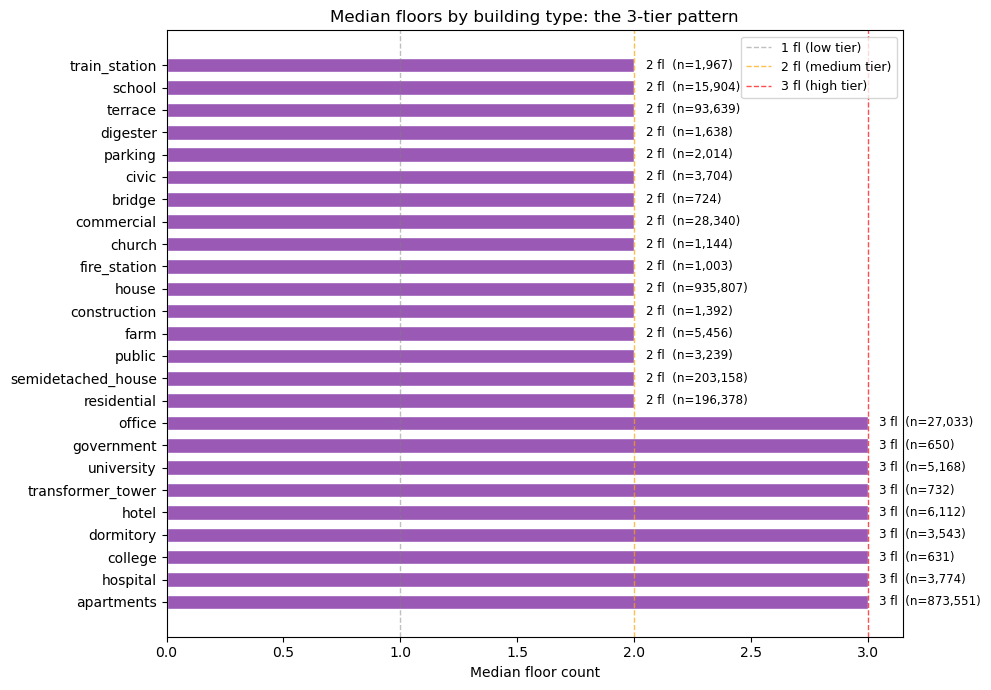

In [31]:
# ── Plot: median floor count by building type ─────────────────────────
type_lev = (gdf_bldg[gdf_bldg['levels_clean'].notna()]
            .groupby('building')['levels_clean']
            .agg(['median','count'])
            .query('count >= 200')
            .sort_values('median', ascending=False)
            .head(25))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(type_lev.index, type_lev['median'],
               color='#9b59b6', edgecolor='white', height=0.65)
for bar, (idx, row) in zip(bars, type_lev.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{row["median"]:.0f} fl  (n={int(row["count"]):,})', va='center', fontsize=8.5)
ax.set_xlabel('Median floor count')
ax.set_title('Median floors by building type: the 3-tier pattern')
ax.axvline(1, color='gray',   linestyle='--', lw=1, alpha=0.5, label='1 fl (low tier)')
ax.axvline(2, color='orange', linestyle='--', lw=1, alpha=0.7, label='2 fl (medium tier)')
ax.axvline(3, color='red',    linestyle='--', lw=1, alpha=0.7, label='3 fl (high tier)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [32]:
gdf_bldg.drop(columns=['building:levels'], inplace=True)
gdf_bldg.rename(columns={'levels_clean': 'building:levels'}, inplace=True)

### Derive Address Completeness

The available address fields are combined into a single categorical feature representing whether a building has no, partial, or complete address information.

- `0` — no address information
- `1` — partial address information
- `2` — complete street, house number, and postcode information

In [33]:
ADDR_COLS = ['addr:street', 'addr:housenumber', 'addr:postcode']
TOTAL = len(gdf_bldg)

available  = [c for c in ADDR_COLS if c in gdf_bldg.columns]

print(f'Address columns used: {available}')
print()

# Count how many of the 3 components each building has
addr_score = gdf_bldg[available].notna().sum(axis=1)

# Map to tier
gdf_bldg['address_tier'] = 0
gdf_bldg.loc[addr_score >= 1, 'address_tier'] = 1   # partial
gdf_bldg.loc[addr_score == len(available), 'address_tier'] = 2  # full

tier_counts = gdf_bldg['address_tier'].value_counts().sort_index()
for tier, cnt in tier_counts.items():
    label = {0: 'No address (industrial/rural signal)',
             1: 'Partial address',
             2: 'Full address (residential signal)'}[tier]
    print(f'  Tier {tier} — {label:<40} : {cnt:>12,}  ({cnt/TOTAL*100:.1f}%)')


Address columns used: ['addr:street', 'addr:housenumber', 'addr:postcode']

  Tier 0 — No address (industrial/rural signal)     :   22,454,480  (57.9%)
  Tier 1 — Partial address                          :    1,595,655  (4.1%)
  Tier 2 — Full address (residential signal)        :   14,752,237  (38.0%)


/tmp/ipykernel_94897/1854283386.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['address_tier'] == 2).sum() / len(x) * 100)


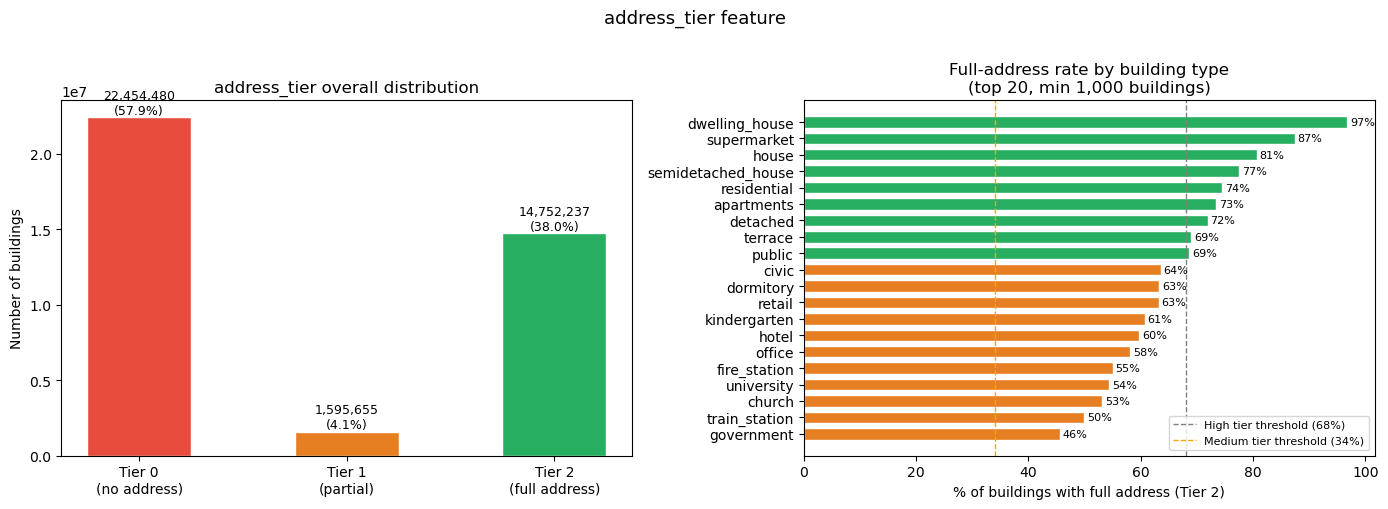

In [34]:
# ── Plot: address tier distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall tier distribution
tier_labels = ['Tier 0\n(no address)', 'Tier 1\n(partial)', 'Tier 2\n(full address)']
tier_vals   = [tier_counts.get(i, 0) for i in range(3)]
colors_t    = ['#e74c3c', '#e67e22', '#27ae60']
bars = axes[0].bar(tier_labels, tier_vals, color=colors_t, edgecolor='white', width=0.5)
for bar, val in zip(bars, tier_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tier_vals)*0.01,
                 f'{val:,}\n({val/TOTAL*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_ylabel('Number of buildings')
axes[0].set_title('address_tier overall distribution')

# Tier-2 rate by building type
MIN_TYPE_COUNT = 1000
type_counts_b  = gdf_bldg['building'].value_counts()
valid_types    = type_counts_b[type_counts_b >= MIN_TYPE_COUNT].index
tier2_by_type  = (gdf_bldg[gdf_bldg['building'].isin(valid_types)]
                  .groupby('building')
                  .apply(lambda x: (x['address_tier'] == 2).sum() / len(x) * 100)
                  .sort_values(ascending=True)
                  .tail(20))

colors_by = ['#27ae60' if v >= 68 else '#e67e22' if v >= 34 else '#e74c3c'
             for v in tier2_by_type]
axes[1].barh(tier2_by_type.index, tier2_by_type.values,
             color=colors_by, edgecolor='white', height=0.7)
axes[1].axvline(68, color='gray', linestyle='--', lw=1, label='High tier threshold (68%)')
axes[1].axvline(34, color='orange', linestyle='--', lw=1, label='Medium tier threshold (34%)')
for i, v in enumerate(tier2_by_type.values):
    axes[1].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)
axes[1].set_xlabel('% of buildings with full address (Tier 2)')
axes[1].set_title('Full-address rate by building type\n(top 20, min 1,000 buildings)')
axes[1].legend(fontsize=8)

plt.suptitle('address_tier feature', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


###  Metric Projections and Spatial Features
EPSG:4326 (WGS84) measures geometries in degrees (Lat/Lon), making area calculation inaccurate. We must project the data to a metric CRS suitable for Europe to calculate footprint area correctly.

In [35]:
# Ensure area_sqm is available (calculated in EDA; recalculate if missing)
if not all(col in gdf_bldg.columns for col in ['area_sqm', 'perimeter_m', 'compactness']):
    print('Recalculating spatial features in EPSG:3035...')
    bproj = gdf_bldg.to_crs(epsg=3035)
    gdf_bldg['area_sqm']    = bproj.geometry.area
    gdf_bldg['perimeter_m'] = bproj.geometry.length
    gdf_bldg['compactness'] = ((4 * np.pi * gdf_bldg['area_sqm']) / (gdf_bldg['perimeter_m'].replace(0, np.nan) ** 2)).clip(0, 1)
    del bproj
    print('Spatial features calculated and added to the GeoDataFrame.')
else:
    print('Spatial features already present — skipping recalculation.')


Recalculating spatial features in EPSG:3035...
Spatial features calculated and added to the GeoDataFrame.


In [36]:
# ── Final dataset summary ─────────────────────────────────────────────
print('═' * 65)
print('FINAL CLEANED DATASET AUDIT')
print('═' * 65)
print(f'  Total buildings      : {len(gdf_bldg):,}')
print(f'  Total columns        : {len(gdf_bldg.columns)}')
print(f'  CRS                  : {gdf_bldg.crs.to_string()}')
print()
print('COLUMN INVENTORY:')
for col in gdf_bldg.columns:
    dtype = str(gdf_bldg[col].dtype)
    n_null = gdf_bldg[col].isna().sum()
    pct_filled = (1 - n_null/len(gdf_bldg)) * 100
    print(f'  {col:<30} {dtype:<15} {pct_filled:>6.1f}% filled')
print('═' * 65)


═════════════════════════════════════════════════════════════════
FINAL CLEANED DATASET AUDIT
═════════════════════════════════════════════════════════════════
  Total buildings      : 38,802,372
  Total columns        : 19
  CRS                  : EPSG:4326

COLUMN INVENTORY:
  addr:city                      object            39.8% filled
  addr:housenumber               object            41.5% filled
  addr:postcode                  object            39.0% filled
  addr:street                    object            41.3% filled
  name                           object             1.5% filled
  building                       object           100.0% filled
  amenity                        object             0.6% filled
  building:use                   object             0.5% filled
  craft                          object             0.0% filled
  office                         object             0.0% filled
  shop                           object             0.2% filled
  id              

In [37]:
gdf_bldg.to_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned02.parquet'), index=False)